Linear Regression

In [490]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import plotly.express as px

In [428]:
from sklearn.datasets import fetch_california_housing  # Import the fetch_california_housing function from sklearn.datasets to load the California Housing dataset.
import pandas as pd  # Import pandas for data manipulation and analysis.
import numpy as np  # Import numpy for numerical computing.

# Load the California Housing dataset using the fetch_california_housing function.
housing = fetch_california_housing()

# Convert the dataset's data into a pandas DataFrame, using the feature names as column headers.
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target variable 'MedHouseValue' to the DataFrame, using the dataset's target values.
housing_df['MedHouseValue'] = housing.target

# Display the first few rows of the DataFrame to get an overview of the dataset.
print(housing_df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  


Check for Missing Values

In [431]:
print(housing_df.isnull().sum())

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64


Feature Selection

In [434]:
correlation_matrix = housing_df.corr()
print(correlation_matrix['MedHouseValue'])

MedInc           0.688075
HouseAge         0.105623
AveRooms         0.151948
AveBedrms       -0.046701
Population      -0.024650
AveOccup        -0.023737
Latitude        -0.144160
Longitude       -0.045967
MedHouseValue    1.000000
Name: MedHouseValue, dtype: float64


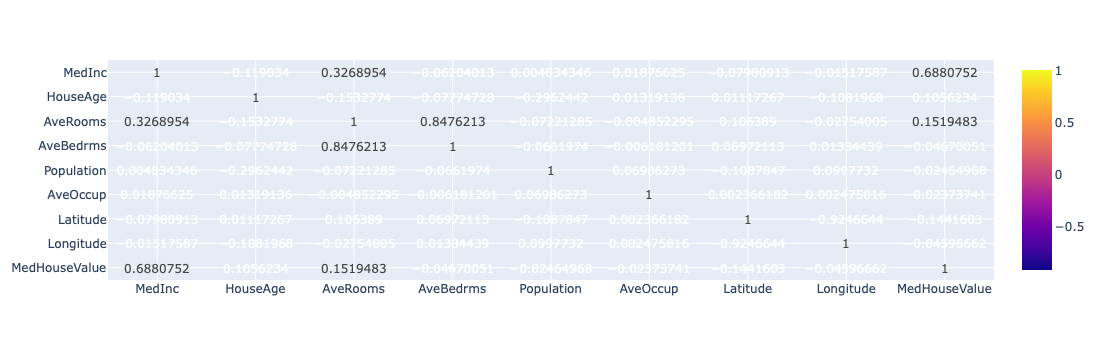

In [465]:
# Plotting the correlation matrix
px.imshow(housing_df.corr(), text_auto=True, aspect="auto")

In [467]:
selected_features = ['MedInc', 'AveRooms', 'AveOccup']
X = housing_df[selected_features]
y = housing_df['MedHouseValue']

Scaling Features

In [470]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the data and transform it
X_scaled = scaler.fit_transform(X)

# Print the scaled data
print(X_scaled)

[[ 2.34476576  0.62855945 -0.04959654]
 [ 2.33223796  0.32704136 -0.09251223]
 [ 1.7826994   1.15562047 -0.02584253]
 ...
 [-1.14259331 -0.09031802 -0.0717345 ]
 [-1.05458292 -0.04021111 -0.09122515]
 [-0.78012947 -0.07044252 -0.04368215]]


Implement Multiple Linear Regression

In [473]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# The 'LinearRegression' model is initialized and fitted to the training data.
model = LinearRegression()
model.fit(X_train, y_train)

# The model is used to predict the target variable for the test set.
y_pred = model.predict(X_test)


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.7006855912225249
R-squared: 0.4652924370503557


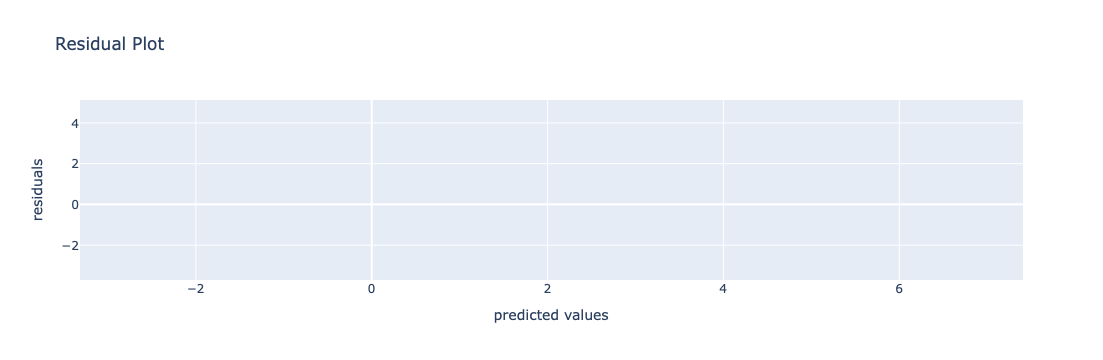

In [475]:
# Residual Plot
residuals = y_test - y_pred
px.scatter(x=y_pred, y=residuals, labels={"x": "predicted values", "y": "residuals"}, title="Residual Plot")

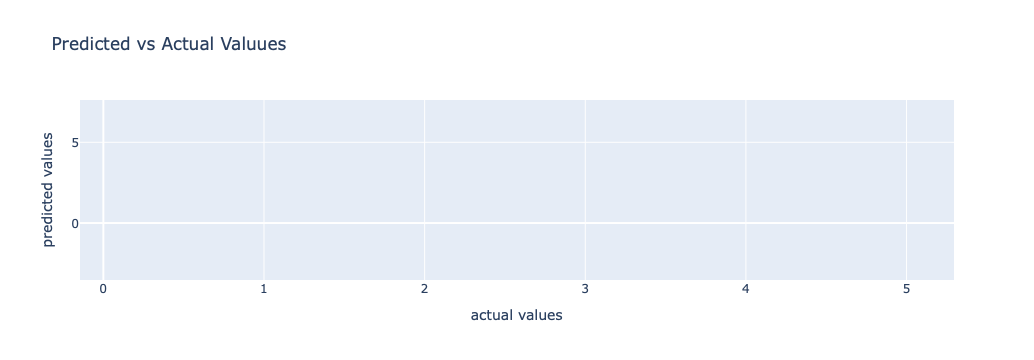

In [478]:
# Predicted vs Actual Plot
px.scatter(x=y_test, y=y_pred, labels={"x": "actual values", "y": "predicted values"}, title="Predicted vs Actual Valuues")

                            OLS Regression Results                            
Dep. Variable:          MedHouseValue   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     5173.
Date:                Thu, 27 Mar 2025   Prob (F-statistic):               0.00
Time:                        21:33:23   Log-Likelihood:                -20354.
No. Observations:               16512   AIC:                         4.072e+04
Df Residuals:                   16508   BIC:                         4.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0679      0.006    320.074      0.0

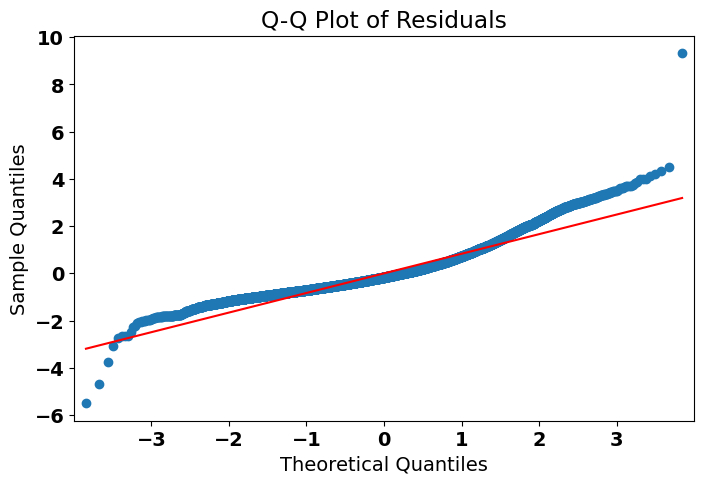

In [480]:
import statsmodels.api as sm

# Add a constant to the model
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

# Q-Q Plot for residuals
sm.qqplot(model_sm.resid, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

Handling Multicollinearity

    Feature       VIF
0    MedInc  1.120166
1  AveRooms  1.119797
2  AveOccup  1.000488


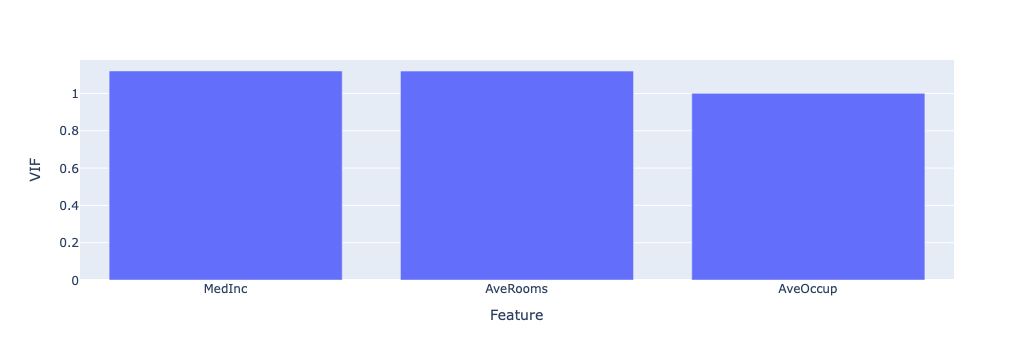

In [483]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = selected_features
vif_data['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
print(vif_data)

# Bar Plot for VIF Values
px.bar(vif_data, x='Feature', y='VIF')

Cross-Validation Techniques

Cross-Validation Scores: [0.42854821 0.37096545 0.46910866 0.31191043 0.51269138]
Mean CV R^2: 0.4186448264400327


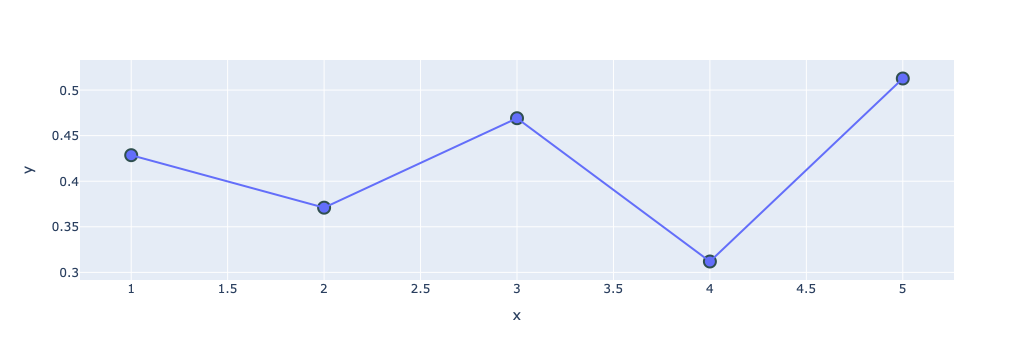

In [459]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("Cross-Validation Scores:", scores)
print("Mean CV R^2:", scores.mean())

# Line Plot for Cross-Validation Scores
fig = px.scatter(x=range(1, 6), y=scores)
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.add_traces(px.line(x=range(1, 6), y=scores).data)

Feature selection methods

Selected Features: [ True  True  True]


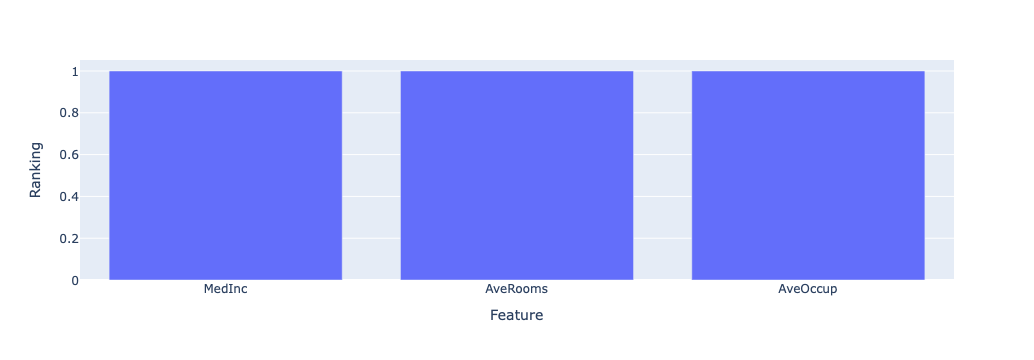

In [487]:
from sklearn.feature_selection import RFE
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_scaled, y)
print("Selected Features:", rfe.support_)

# Bar Plot of Feature Rankings
feature_ranking = pd.DataFrame({
   'Feature': selected_features,
   'Ranking': rfe.ranking_
})
px.bar(feature_ranking.sort_values(by='Ranking'), x='Feature', y='Ranking')